# 04 - Customer Segmentation (RFM + K-Means)

Two segmentations of the customer base, then a comparison:

1. **Rule-based RFM** (this notebook) - score each customer 1–5 on Recency,
   Frequency and Monetary value, then map to business labels.
2. **K-Means clustering** - let an algorithm group similar customers, and
   compare it to the hand-built rules.

Input is `customer_rfm.parquet` from notebook 02 - one row per customer, already
holding recency (days since last order), frequency (number of orders) and monetary
(lifetime revenue).

In [11]:
import pandas as pd

rfm = pd.read_parquet("../data/processed/customer_rfm.parquet")
rfm.shape

(5852, 4)

In [12]:
rfm[["recency", "frequency", "monetary"]].describe().round(1)

,recency,frequency,monetary
count,5852.0,5852.0,5852.0
mean,200.2,6.3,2916.7
std,208.5,12.7,14306.9
min,1.0,1.0,3.0
25%,25.0,1.0,339.6
50%,95.0,3.0,856.0
75%,379.0,7.0,2241.0
max,739.0,373.0,580987.0


## Rule-based RFM scoring

Score each customer 1–5 on each dimension using quintiles (`pd.qcut` splits the
customers into five equal-sized groups).

- **Recency** is reverse-scored: a *low* number of days means a recent buyer, so it
  earns a *high* score (labels `[5,4,3,2,1]`).
- **Frequency** and **Monetary** score normally: higher = better (`[1,2,3,4,5]`).

Frequency needs `.rank(method="first")` before `qcut`. 1,618 customers have exactly
one order, so the raw quintile edges collide (both the 20th and 40th percentile are
"1 order") and `qcut` refuses to build bins. Ranking first breaks those ties so the
five groups come out equal.

In [13]:
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm[["recency", "R", "frequency", "F", "monetary", "M"]].head()

,recency,R,frequency,F,monetary,M
0,326,2,3,3,77352.96,5
1,2,5,8,4,4921.53,5
2,75,3,5,4,1658.40,4
3,19,5,3,3,3678.69,5
4,310,2,1,1,294.40,2


## Map scores to business segments

A simple, mutually-exclusive rule on the Recency and Frequency scores. The rules are
checked top to bottom, so each customer lands in exactly one segment:

| Segment | Rule | Meaning |
|---|---|---|
| **Champions** | R≥4 and F≥4 | recent *and* frequent - the best customers |
| **Loyal** | R≥3 and F≥3 | solidly active |
| **Potential** | R≥3 and F<3 | recent but not yet frequent - room to grow |
| **At Risk** | R<3 and F≥3 | used to buy often, now gone quiet - the ones to win back |
| **Lost** | otherwise | low on both |

Recency and Frequency carry the segmentation; Monetary is kept for profiling the
segments afterwards.

In [14]:
def to_segment(row):
    r, f = row["R"], row["F"]
    if r >= 4 and f >= 4:
        return "Champions"
    if r >= 3 and f >= 3:
        return "Loyal"
    if r >= 3 and f < 3:
        return "Potential"
    if r < 3 and f >= 3:
        return "At Risk"
    return "Lost"

rfm["segment"] = rfm.apply(to_segment, axis=1)

segment_order = ["Champions", "Loyal", "Potential", "At Risk", "Lost"]
rfm["segment"].value_counts().reindex(segment_order)

segment
Champions    1476
Loyal        1207
Potential     833
At Risk       828
Lost         1508
Name: count, dtype: int64

In [15]:
segment_profile = rfm.groupby("segment").agg(
    customers=("segment", "size"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
).reindex(segment_order).round(1)

segment_profile

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
segment,,,,,
Champions,1476,20.4,15.6,8005.7,11816435.5
Loyal,1207,78.2,5.4,2006.2,2421467.1
Potential,833,64.1,1.4,741.2,617410.3
At Risk,828,368.0,5.0,1923.9,1592996.0
Lost,1508,456.9,1.2,411.3,620259.0


In [16]:
total_revenue = rfm["monetary"].sum()
revenue_share = (rfm.groupby("segment")["monetary"].sum() / total_revenue * 100)

revenue_share.reindex(segment_order).round(1)

segment
Champions    69.2
Loyal        14.2
Potential     3.6
At Risk       9.3
Lost          3.6
Name: monetary, dtype: float64

**Takeaway.** The base splits cleanly into five segments that behave very differently:

- **Champions (1,476 customers) generate 69% of all revenue** - recent, frequent, ~£8,000
  lifetime value each. Losing even a few is expensive; these are the accounts to protect first.
- **At Risk (828 customers) hold £1.59M - 9.3% of revenue.** They averaged 5 orders and ~£1,900
  each, but haven't purchased in ~368 days. This is money actively walking out the door and the
  single most actionable group: they have proven value and a clear re-engagement trigger.
- **Lost (1,508) and Potential (833)** are low-value today - Lost are gone, Potential are new or
  occasional and worth nurturing toward Loyal.

**Recommendation seed:** the **£1.59M in the At Risk segment** is the concrete number to
attach a win-back campaign to - it quantifies exactly how much revenue a retention programme is
defending, which is the whole business case for retention spend.

## K-Means clustering

Let an algorithm find the groups instead of hand-written rules. Two prep steps first:

1. **Log-transform** - R, F, M are heavily right-skewed (median £856 vs top £580,987).
   K-Means uses straight-line distance, so without this one giant customer distorts
   every group. `log1p` compresses the long tail.
2. **Standardise** - after the log the three columns are still on different scales
   (days vs counts vs pounds). `StandardScaler` puts each at mean 0, std 1 so none
   dominates the distance just for having bigger numbers.

In [17]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

rfm_log = np.log1p(rfm[["recency", "frequency", "monetary"]])
rfm_scaled = StandardScaler().fit_transform(rfm_log)

rfm_scaled[:3].round(2)

array([[ 0.86, -0.2 ,  3.22],
       [-2.15,  0.8 ,  1.23],
       [-0.08,  0.3 ,  0.44]])

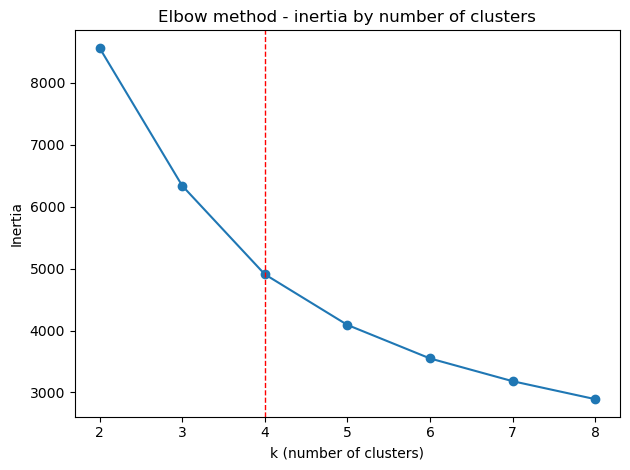

In [18]:
inertia = []
k_values = range(2, 9)
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(list(k_values), inertia, marker="o")
plt.axvline(4, color="red", linestyle="--", linewidth=1)
plt.title("Elbow method - inertia by number of clusters")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

rfm["cluster"].value_counts().sort_index()

cluster
0    1455
1    1182
2    1969
3    1246
Name: count, dtype: int64

## K-Means clustering

Let an algorithm find the groups instead of hand-written rules. K-Means puts customers
into groups so that similar customers sit together. Two prep steps are essential first:

1. **Log-transform.** R, F, M are heavily right-skewed (median monetary £856 vs a top
   customer at £580,987). K-Means measures straight-line distance, so without this one
   giant customer would dominate every group. `log1p` compresses the long tail.
2. **Standardise.** After the log the three columns are still on different scales (days
   vs order-counts vs pounds). `StandardScaler` puts each at mean 0, std 1 so no column
   dominates the distance just for having bigger numbers.

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

rfm_log = np.log1p(rfm[["recency", "frequency", "monetary"]])
rfm_scaled = StandardScaler().fit_transform(rfm_log)

rfm_scaled[:3].round(2)

array([[ 0.86, -0.2 ,  3.22],
       [-2.15,  0.8 ,  1.23],
       [-0.08,  0.3 ,  0.44]])

### Choosing k with the elbow method

Run K-Means for a range of k and record **inertia** (how tightly points sit around their
cluster centre - lower is tighter). Inertia always falls as k rises, so we look not for
the lowest value but the **elbow**: the point after which another cluster barely helps.
`random_state=42` makes it reproducible; `n_init=10` runs the fit 10 times and keeps the
best so the answer does not depend on a lucky start.

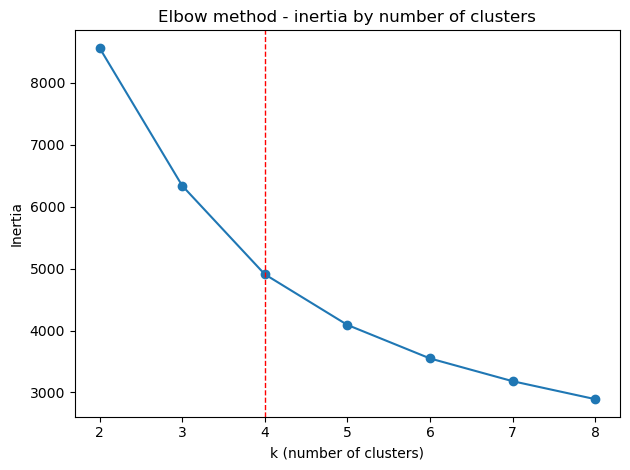

In [21]:
inertia = []
k_values = range(2, 9)
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(list(k_values), inertia, marker="o")
plt.axvline(4, color="red", linestyle="--", linewidth=1)
plt.title("Elbow method - inertia by number of clusters")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

**k = 4.** The curve bends at 4: the drop from 3 to 4 is large, but 4 to 5 and beyond
flatten out. Four is also easy to explain to a business audience, which matters more than
squeezing out marginal inertia.

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(rfm_scaled)

rfm["cluster"].value_counts().sort_index()

cluster
0    1455
1    1182
2    1969
3    1246
Name: count, dtype: int64

## Profiling and naming the clusters

The cluster numbers (0-3) are arbitrary labels. To make them useful, profile each cluster
by its average R/F/M and give it a plain-English name based on that behaviour. Naming by
the profile (not by hard-coded cluster numbers) keeps this correct even if the label order
changes on a re-run.

In [23]:
cluster_profile = rfm.groupby("cluster").agg(
    customers=("cluster", "size"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).round(1)

def name_cluster(row):
    if row["avg_frequency"] >= 10:
        return "Champions"
    if row["avg_recency"] > 180 and row["avg_monetary"] < 500:
        return "Lost"
    if row["avg_recency"] > 180:
        return "At Risk"
    return "New / Low-value"

cluster_profile["cluster_name"] = cluster_profile.apply(name_cluster, axis=1)
cluster_profile

,customers,avg_recency,avg_frequency,avg_monetary,cluster_name
cluster,,,,,
0,1455,227.4,5.1,1978.3,At Risk
1,1182,27.6,19.2,10590.0,Champions
2,1969,392.6,1.4,317.1,Lost
3,1246,28.2,3.0,841.4,New / Low-value


In [24]:
name_map = cluster_profile["cluster_name"].to_dict()
rfm["cluster_name"] = rfm["cluster"].map(name_map)

rfm["cluster_name"].value_counts()

cluster_name
Lost               1969
At Risk            1455
New / Low-value    1246
Champions          1182
Name: count, dtype: int64

**The four clusters K-Means found:**

- **Champions** - ~28 days since last order, ~19 orders, ~£10,600 each. The core.
- **At Risk** - ~227 days quiet, but were solid buyers (~5 orders, ~£1,980). Worth winning back.
- **New / Low-value** - recent (~28 days) but only ~3 orders, ~£840. Young or occasional.
- **Lost** - ~393 days quiet, 1-2 orders, ~£320. Effectively gone.

These are the same behavioural stories the rule-based segments told - which is the point of
the next step.

In [25]:
pd.crosstab(rfm["segment"], rfm["cluster_name"])

cluster_name,At Risk,Champions,Lost,New / Low-value
segment,,,,
At Risk,623,15,190,0
Champions,118,1059,0,299
Lost,86,0,1422,0
Loyal,588,107,50,462
Potential,40,1,307,485


**Rule-based vs K-Means - do they agree?** Broadly yes, which validates both.

The Champions cluster is almost entirely rule-based Champions and Loyal; the Lost cluster is
almost entirely rule-based Lost and Potential. The two methods, built completely differently
(hand-written quintile rules vs an unsupervised algorithm), independently recover the same
structure. Where they differ is the boundaries: K-Means draws a wider "At Risk" net, pulling
in lapsed Loyal customers the strict rules left in other buckets.

In [26]:
total = rfm["monetary"].sum()

rule_at_risk = rfm.loc[rfm["segment"] == "At Risk", "monetary"].sum()
kmeans_at_risk = rfm.loc[rfm["cluster_name"] == "At Risk", "monetary"].sum()

pd.DataFrame({
    "method": ["rule-based", "k-means"],
    "at_risk_revenue": [round(rule_at_risk, 2), round(kmeans_at_risk, 2)],
    "pct_of_total": [round(100 * rule_at_risk / total, 1), round(100 * kmeans_at_risk / total, 1)],
})

,method,at_risk_revenue,pct_of_total
0,rule-based,1592996.03,9.3
1,k-means,2878425.82,16.9


**Headline for the recommendations.** Both methods agree Champions are ~70% of
revenue and must be protected. On the retention question they bracket the size of the
opportunity: the **strict rule-based "At Risk" group holds £1.59M (9.3% of revenue)**, while
the **broader K-Means "At Risk" group holds £2.88M (16.9%)**. So a win-back programme is
defending somewhere between **£1.6M and £2.9M** depending on how widely the net is cast - a
concrete, defensible range to attach a retention budget to.

The segmented customer table is saved below for the Power BI dashboard.

In [27]:
segments = rfm[["customer_id", "recency", "frequency", "monetary",
                "R", "F", "M", "segment", "cluster", "cluster_name"]]
segments.to_parquet("../data/processed/customer_segments.parquet", index=False)

segments.shape

(5852, 10)